# Editing Fraser River Hydrograph

In [1]:
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 2018

In [2]:
path = Path("/results/forcing/rivers/")
data = xr.open_mfdataset(sorted(path.glob(f"R202108Dailies_y2018*")), combine='nested', concat_dim='time_counter')

In [3]:
data

<xarray.Dataset> Size: 1GB
Dimensions:       (time_counter: 365, y: 898, x: 398)
Coordinates:
  * time_counter  (time_counter) int64 3kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
  * y             (y) int64 7kB 0 1 2 3 4 5 6 7 ... 891 892 893 894 895 896 897
  * x             (x) int64 3kB 0 1 2 3 4 5 6 7 ... 391 392 393 394 395 396 397
Data variables:
    rorunoff      (time_counter, y, x) float64 1GB dask.array<chunksize=(1, 898, 398), meta=np.ndarray>
Attributes:
    acknowledgements:      Based on river fit
    creator_email:         sallen@eoas.ubc.ca
    creator_name:          Salish Sea MEOPAR Project Contributors
    creator_url:           https://salishsea-meopar-docs.readthedocs.org/
    institution:           UBC EOAS
    institution_fullname:  Earth, Ocean & Atmospheric Sciences, University of...
    title:                 Rivers for y2018m01d01
    notebook:              MakeDailyRiverNCfiles.ipynb
    rivers_base:           river_202108
    summary:               Daily Runoff for Bathymetry 202108
    history:               [2021-09-23] File creation.

In [4]:
# location of fraser
np.unravel_index(data.rorunoff.values.argmax(), data.rorunoff.values.shape)

# so fraser is located at y=500, x=394
runoff = data.rorunoff[:,500,394].values

In [5]:
# unit conversion (will convert from our targets to the SalishSeaCast units, not the other way around)
# Runoff is input as rainfall into a cell, kg m-2 s-1
# to convert to m3 s-1 you need to multiply by the area of the cell (~500x500) and divide by the density of water (~998) = ~250.5
# so, divide our targets by 250.5 to get them into the model units

peakchange = 1000/250.5 # want peak flow to be about 1000 less than before
minchange = (200+170)/250.5 # want minimum flow to be about 200 more than before
total = np.sum(runoff) # don't want total to significantly change
# had to increase minchange by 170 to get transports to remain the same
# more flattenning than suggested in Morrison2002

print(f"target peak= ~{runoff.max() - peakchange} kg m-2 s-1")
print(f"min change= {minchange} kg m-2 s-1")
print(f'total = {total} kg m-2 s-1')

target peak= ~55.950837732294445 kg m-2 s-1
min change= 1.4770459081836327 kg m-2 s-1
total = 5956.569648804018 kg m-2 s-1


In [6]:
# first, multiply by a factor such that the peak flow is less by peakchange+minchange
factor = (runoff.max() - peakchange - minchange)/runoff.max()
newrun = runoff*factor
print(f"factor = {factor}")

# then add the minchange 
newrun = newrun + minchange

factor = 0.9087620702279843


In [7]:
np.sum(newrun) # slightly lower total than before
# 3% decrease when morrison had 3% increase
# likely because the 

np.float64(5952.226321991342)

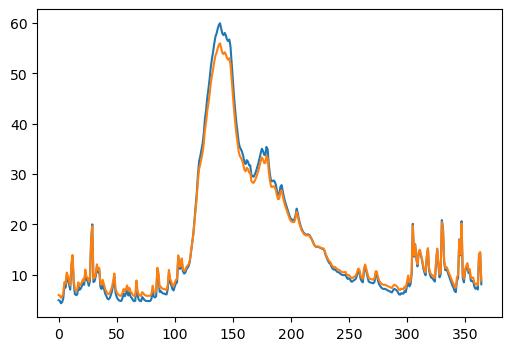

In [8]:
fig, ax = plt.subplots(1,1,figsize=[6,4])

ax.plot(runoff)
ax.plot(newrun)

# 2019

In [ ]:
data = xr.open_mfdataset(sorted(path.glob(f"R202108Dailies_y2019*")), combine='nested', concat_dim='time_counter')
runoff = data.rorunoff[:,500,394].values

In [10]:
total = np.sum(runoff) # don't want total to significantly change

print(f"target peak= ~{runoff.max() - peakchange} kg m-2 s-1")
print(f"min change= {minchange} kg m-2 s-1")
print(f'total = {total} kg m-2 s-1')

target peak= ~34.86766702333626 kg m-2 s-1
min change= 1.4770459081836327 kg m-2 s-1
total = 5688.39477826753 kg m-2 s-1


In [11]:
# first, multiply by a factor such that the peak flow is less by peakchange+minchange
factor = (runoff.max() - peakchange - minchange)/runoff.max()
newrun = runoff*factor
print(f"factor = {factor}")

# then add the minchange 
newrun = newrun + minchange

factor = 0.8592612843121278


In [12]:
np.sum(newrun) # lower total than before

np.float64(5426.939159335586)

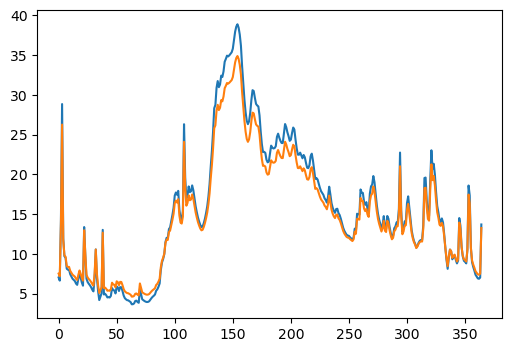

In [13]:
fig, ax = plt.subplots(1,1,figsize=[6,4])

ax.plot(runoff)
ax.plot(newrun)

## 2020

In [ ]:
data = xr.open_mfdataset(sorted(path.glob(f"R202108Dailies_y2020*")), combine='nested', concat_dim='time_counter')
runoff = data.rorunoff[:,500,394].values

In [15]:
total = np.sum(runoff) # don't want total to significantly change

print(f"target peak= ~{runoff.max() - peakchange} kg m-2 s-1")
print(f"min change= {minchange} kg m-2 s-1")
print(f'total = {total} kg m-2 s-1')

target peak= ~54.49921705827938 kg m-2 s-1
min change= 1.4770459081836327 kg m-2 s-1
total = 7899.932266896639 kg m-2 s-1


In [16]:
# first, multiply by a factor such that the peak flow is less by peakchange+minchange
factor = (runoff.max() - peakchange - minchange)/runoff.max()
newrun = runoff*factor
print(f"factor = {factor}")

# then add the minchange 
newrun = newrun + minchange

factor = 0.9064977502904691


In [17]:
np.sum(newrun) # lower total than before

np.float64(7701.869629784099)

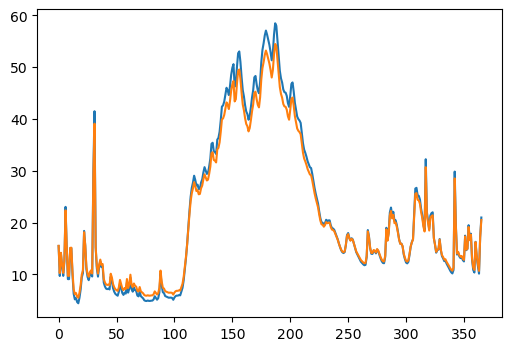

In [18]:
fig, ax = plt.subplots(1,1,figsize=[6,4])

ax.plot(runoff)
ax.plot(newrun)

## 2021

In [19]:
data = xr.open_mfdataset(sorted(path.glob(f"R202108Dailies_y2021*")), combine='nested', concat_dim='time_counter')
runoff = data.rorunoff[:,500,394].values

In [20]:
total = np.sum(runoff) # don't want total to significantly change

print(f"target peak= ~{runoff.max() - peakchange} kg m-2 s-1")
print(f"min change= {minchange} kg m-2 s-1")
print(f'total = {total} kg m-2 s-1')

target peak= ~69.0736004345686 kg m-2 s-1
min change= 1.4770459081836327 kg m-2 s-1
total = 6502.978327474299 kg m-2 s-1


In [21]:
# first, multiply by a factor such that the peak flow is less by peakchange+minchange
factor = (runoff.max() - peakchange - minchange)/runoff.max()
newrun = runoff*factor
print(f"factor = {factor}")

# then add the minchange 
newrun = newrun + minchange

factor = 0.9251486246812741


In [22]:
np.sum(newrun) # lower total than before

np.float64(6555.343212482005)

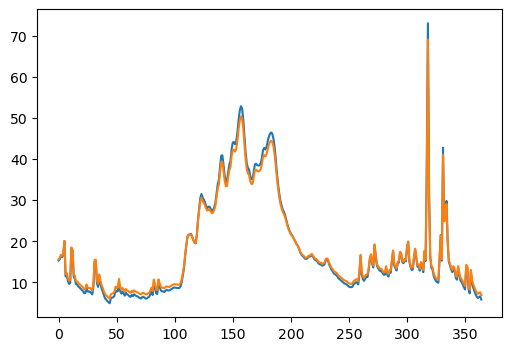

In [23]:
fig, ax = plt.subplots(1,1,figsize=[6,4])

ax.plot(runoff)
ax.plot(newrun)

## 2022

In [24]:
data = xr.open_mfdataset(sorted(path.glob(f"R202108Dailies_y2022*")), combine='nested', concat_dim='time_counter')
runoff = data.rorunoff[:,500,394].values

In [25]:
total = np.sum(runoff) # don't want total to significantly change

print(f"target peak= ~{runoff.max() - peakchange} kg m-2 s-1")
print(f"min change= {minchange} kg m-2 s-1")
print(f'total = {total} kg m-2 s-1')

target peak= ~53.17602918137077 kg m-2 s-1
min change= 1.4770459081836327 kg m-2 s-1
total = 6335.309774684826 kg m-2 s-1


In [26]:
# first, multiply by a factor such that the peak flow is less by peakchange+minchange
factor = (runoff.max() - peakchange - minchange)/runoff.max()
newrun = runoff*factor
print(f"factor = {factor}")

# then add the minchange 
newrun = newrun + minchange

factor = 0.9043335859753183


In [27]:
np.sum(newrun) # lower total than before

np.float64(6268.355163292241)

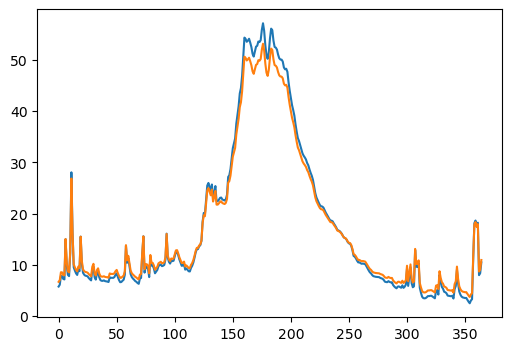

In [28]:
fig, ax = plt.subplots(1,1,figsize=[6,4])

ax.plot(runoff)
ax.plot(newrun)